#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> What is the total revenue and total orders by product category?

> Which region contributes the highest percentage of total revenue?

> What is the return rate (%) by category?

> Which category has the highest average order value?

> Rank all categories by total revenue — highest to lowest.

In [2]:
# E-commerce order data for Arjun's store
data = {
    'Order_ID': ['O001','O002','O003','O004','O005','O006','O007','O008',
                 'O009','O010','O011','O012','O013','O014','O015'],

    'Region': ['North','South','West','East','North','South','West','East',
               'North','South','West','East','North','West','South'],

    'Category': ['Electronics','Clothing','Electronics','Home Decor','Clothing',
                 'Electronics','Home Decor','Clothing','Electronics','Home Decor',
                 'Clothing','Electronics','Home Decor','Clothing','Electronics'],

    'Orders': [12, 25, 8, 30, 18, 15, 22, 35, 10, 28, 20, 14, 16, 40, 11],

    'Revenue': [36000, 12500, 24000, 9000, 9000, 45000, 6600, 17500,
                30000, 8400, 10000, 42000, 4800, 20000, 33000],

    'Returned_Orders': [1, 3, 0, 2, 2, 1, 1, 4, 1, 3, 2, 0, 1, 5, 2]
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Create DataFrame from given order data
data_frame = pd.DataFrame(data)

data_frame

,Order_ID,Region,Category,Orders,Revenue,Returned_Orders
0,O001,North,Electronics,12,36000,1
1,O002,South,Clothing,25,12500,3
2,O003,West,Electronics,8,24000,0
3,O004,East,Home Decor,30,9000,2
4,O005,North,Clothing,18,9000,2
5,O006,South,Electronics,15,45000,1
6,O007,West,Home Decor,22,6600,1
7,O008,East,Clothing,35,17500,4
8,O009,North,Electronics,10,30000,1
9,O010,South,Home Decor,28,8400,3


#### `Step 2 :- Add Return Rate Column`

In [4]:
# Calculate return rate (%) per order
data_frame['Return_Rate'] = round((data_frame['Returned_Orders'] / data_frame['Orders']) * 100, 2)

data_frame

,Order_ID,Region,Category,Orders,Revenue,Returned_Orders,Return_Rate
0,O001,North,Electronics,12,36000,1,8.33
1,O002,South,Clothing,25,12500,3,12.00
2,O003,West,Electronics,8,24000,0,0.00
3,O004,East,Home Decor,30,9000,2,6.67
4,O005,North,Clothing,18,9000,2,11.11
5,O006,South,Electronics,15,45000,1,6.67
6,O007,West,Home Decor,22,6600,1,4.55
7,O008,East,Clothing,35,17500,4,11.43
8,O009,North,Electronics,10,30000,1,10.00
9,O010,South,Home Decor,28,8400,3,10.71


#### `Step 3 :- Add Average Order Value Column`

In [5]:
# Calculate average order value per order
data_frame['Average_Order_Value'] = round((data_frame['Revenue'] / data_frame['Orders']), 2)

data_frame

,Order_ID,Region,Category,Orders,Revenue,Returned_Orders,Return_Rate,Average_Order_Value
0,O001,North,Electronics,12,36000,1,8.33,3000.0
1,O002,South,Clothing,25,12500,3,12.00,500.0
2,O003,West,Electronics,8,24000,0,0.00,3000.0
3,O004,East,Home Decor,30,9000,2,6.67,300.0
4,O005,North,Clothing,18,9000,2,11.11,500.0
5,O006,South,Electronics,15,45000,1,6.67,3000.0
6,O007,West,Home Decor,22,6600,1,4.55,300.0
7,O008,East,Clothing,35,17500,4,11.43,500.0
8,O009,North,Electronics,10,30000,1,10.00,3000.0
9,O010,South,Home Decor,28,8400,3,10.71,300.0


#### `Step 4 :- Average Order Value by Category`

In [14]:
# Group by category and calculate mean of Average_Order_Value
category_average_order_value = data_frame.groupby('Category')['Average_Order_Value'].mean().round(2)

category_average_order_value

Category
Clothing        500.0
Electronics    3000.0
Home Decor      300.0
Name: Average_Order_Value, dtype: float64

#### `Step 5 :- Total Revenue and Orders by Category`

In [6]:
# Group by category and calculate total revenue and total orders
category_summary = data_frame.groupby('Category').agg(Total_Revenue = ('Revenue', 'sum'), Total_Orders = ('Orders', 'sum')).reset_index()

category_summary

,Category,Total_Revenue,Total_Orders
0,Clothing,69000,138
1,Electronics,210000,70
2,Home Decor,28800,96


#### `Step 6 :- Revenue Contribution % by Region`

In [7]:
# Calculate revenue percentage contribution by region
region_revenue = data_frame.groupby('Region')['Revenue'].sum()

total_revenue = region_revenue.sum()

region_contribution = round((region_revenue / total_revenue) * 100, 2)

region_contribution

Region
East     22.25
North    25.93
South    32.13
West     19.69
Name: Revenue, dtype: float64

#### `Step 7 :- Return Rate % by Category`

In [8]:
# Group by category and calculate mean return rate
category_return_rate = data_frame.groupby('Category')['Return_Rate'].mean().round(2)

category_return_rate

Category
Clothing       11.41
Electronics     7.20
Home Decor      7.04
Name: Return_Rate, dtype: float64

#### `Step 8 :- Rank Categories by Total Revenue`

In [9]:
# Sort categories by total revenue descending
ranked_categories = category_summary.sort_values(by = 'Total_Revenue', ascending = False)

ranked_categories

,Category,Total_Revenue,Total_Orders
1,Electronics,210000,70
0,Clothing,69000,138
2,Home Decor,28800,96


#### `Step 9 :- Chart 1 — Total Revenue by Category`

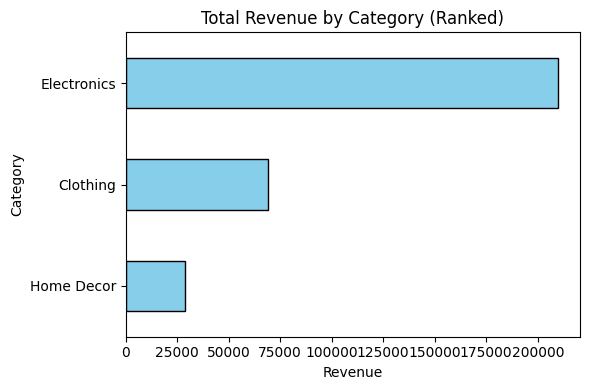

In [15]:
# Horizontal bar chart showing total revenue per category
plt.figure(figsize = (6, 4))

category_summary.sort_values('Total_Revenue', ascending = True).set_index('Category')['Total_Revenue'].plot(kind = 'barh', color = 'skyblue', edgecolor = 'black')

plt.title('Total Revenue by Category (Ranked)')

plt.xlabel('Revenue')

plt.ylabel('Category')

plt.tight_layout()

plt.savefig('3_Insights_Total_Revenue_by_Category.png')

plt.show()

#### `Step 10 :- Chart 2 — Revenue Contribution % by Region`

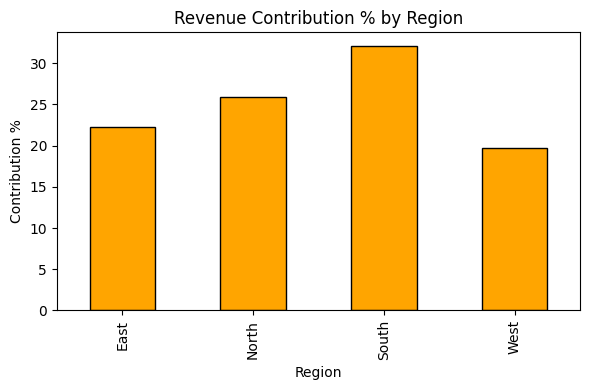

In [11]:
# Bar chart showing revenue contribution percentage by region
plt.figure(figsize = (6, 4))

region_contribution.plot(kind = 'bar', color = 'orange', edgecolor = 'black')

plt.title('Revenue Contribution % by Region')

plt.xlabel('Region')

plt.ylabel('Contribution %')

plt.tight_layout()

plt.savefig('3_Insights_Revenue_Contribution_by_Region.png')

plt.show()

#### `Step 11 :- Print Outputs`

In [16]:
print(f'\nCategory Summary:\n{category_summary}')

print(f'\nRegion Contribution %:\n{region_contribution}')

print(f'\nCategory Return Rate %:\n{category_return_rate}')

print(f'\nCategory Average Order Value:\n{category_average_order_value}')

print(f'\nRanked Categories:\n{ranked_categories}')


Category Summary:
      Category  Total_Revenue  Total_Orders
0     Clothing          69000           138
1  Electronics         210000            70
2   Home Decor          28800            96

Region Contribution %:
Region
East     22.25
North    25.93
South    32.13
West     19.69
Name: Revenue, dtype: float64

Category Return Rate %:
Category
Clothing       11.41
Electronics     7.20
Home Decor      7.04
Name: Return_Rate, dtype: float64

Category Average Order Value:
Category
Clothing        500.0
Electronics    3000.0
Home Decor      300.0
Name: Average_Order_Value, dtype: float64

Ranked Categories:
      Category  Total_Revenue  Total_Orders
1  Electronics         210000            70
0     Clothing          69000           138
2   Home Decor          28800            96


#### `Information`
> Rows: 15

> Columns: 8 (Order_ID, Region, Category, Orders, Revenue, Returned_Orders, Return_Rate, Avg_Order_Value)

> No missing values

#### `Data Insights`
> Electronics generated the highest revenue (₹210,000).

> Clothing had the highest number of orders (138).

> South region contributed the most revenue (32.13%).

> Return rate is highest in Clothing (11.41%).

> Electronics has the highest average order value (₹3000).

#### `Business Insights`
> Electronics is the most profitable category despite fewer orders — high ticket size.

> Clothing drives customer traffic but suffers from high return rate.

> South region is the strongest contributor, followed closely by North.

> Home Decor is underperforming both in revenue and average order value.

#### `Risks`
> High return rate in Clothing could signal quality or sizing issues.

> Over‑dependence on Electronics revenue — risky if demand slows.

> Home Decor may drain resources if not improved.

#### `Opportunities`
> Improve product quality and sizing in Clothing to reduce returns.

> Expand Electronics marketing in South and North regions.

> Introduce premium Home Decor items to raise average order value.

#### `Recommendations`
> Focus investor pitch on Electronics growth potential.

> Implement stricter quality checks in Clothing to cut return rate.

> Launch targeted campaigns in South region to maximize revenue.

> Quantify impact: Reducing Clothing return rate from 11.41% to 5% could save ~₹3,900 in lost order value.

#### `Expected Business Impact`
> Lower returns → higher net revenue.

> Stronger Electronics focus → investor confidence.

> Regional campaigns → sustained growth in South and North.

#### `Future Prediction`
> Electronics will remain the top revenue driver.

> Clothing will continue to attract orders but needs return control.

> South region will likely stay the strongest contributor.

> Home Decor may stagnate unless repositioned.